# Scale cuts: PP plots and FoB

Compares inference checkpoints with different bispectrum (`_kb*`) or PGM (`_kpgm*`) masks on the **coverage** test set. Setup matches `2026-04-05_inference_best-rand30.ipynb` (`_best-rand30`, `bx=32`, `n_train=10000`).

- **PP plot:** rank $r_i$ = fraction of posterior draws with $\theta^{(j)} < \theta_\mathrm{true}$ (strict); empirical CDF vs black dashed uniform diagonal; **KS** $p$-value in the legend; one subplot per parameter.
- **FoB:** unsigned only (see plot title for FoB $= |\hat\theta-\theta_{\mathrm{true}}|/\sigma$). Values are row-averaged per parameter; **coverage** plots show mean $\pm$ std over coverage rows vs $k_\mathrm{max}$, horizontal line at $\sqrt{2/\pi}$ (*expected if Gaussian*). **SHAMe:** same statistic; $y$-axis from 0.

**Bispectrum loose cut:** use **`_kb0.4`** in `TAGS_KMAX_KB` (not an empty string). `collect_chains` tries `_kb0.4` then falls back to `""` if you only have a no-suffix `pk_bispec` checkpoint. **PGM** loose cut keeps an **empty** suffix in `TAGS_KMAX_KPGM`, plotted at $k_\mathrm{max}=0.4$.

If the `_kb0.4` curve is skipped, generate `samples_test...coverage..._pred.npy` for that run (inference test on the coverage preset).


In [1]:
import sys
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from scipy.stats import gaussian_kde, kstest

import data_loader
import paths
import utils_inference
import utils_plot
import plotter
import generate_params as genp


In [2]:
# --- match 2026-04-05_inference_best-rand30 (noisy coverage) ---
bx = 32
n_train = 10000
TAG_INF_BEST_SUFFIX = "_best-rand30"

data_mode = "muchisimocks"
TAG_PARAMS_TRAIN = "_p5_n10000"
TAG_BIASPARAMS_TRAIN_NOISY = "_biasnoisenest_p9_n320000"
TAG_NOISE_TRAIN = "_noise_unit_p5_n10000"
tag_reparam = "_rp"

TAG_PARAMS_TEST_COV = "_coverage_p5_n1000"
TAG_BIASPARAMS_TEST_COV_NOISY = "_biasnoisecoverage_p9_n1000"
TAG_NOISE_TEST_COV = "_noise_unit_coverage_p5_n1000"

STAT_ROW_KB = ["pk", "bispec"]
STAT_ROW_KPGM = ["pk", "pgm"]

# Bispectrum: explicit _kb0.4 for loosest (see notebook intro); PGM: empty suffix for loosest.
TAGS_KMAX_KB = ["_kb0.1", "_kb0.15", "_kb0.2", "_kb0.25", "_kb0.3", "_kb0.35", "_kb0.4"]
TAGS_KMAX_KPGM = ["_kpgm0.1", "_kpgm0.15", "_kpgm0.2", "_kpgm0.25", "_kpgm0.3", "_kpgm0.35", ""]

KMAX_PLOT_LOOSE = 0.4  # numeric x for PGM empty suffix

# OOD SHAMe (``utils_model.bias_dict_shame``)
DATA_MODE_TEST_SHAME = "shame"
TAG_MOCK_SHAME = "_nbar0.00022"  # legacy single-mock default
TAG_MOCKS_SHAME = ["_nbar0.00011", "_nbar0.00022", "_nbar0.00054"]
# Parameter colors (green, blue, purple) — same order as ``param_names_show`` / subplots
PARAM_COLORS = ("#2ca02c", "#1f77b4", "#9467bd")
# Secondary encoding by linestyle (k_max index or SHAMe mock index); flipped from (−, −−, :)
LINE_STYLES_CYCLE = (":", "--", "-")
LINE_STYLES_SHAME = LINE_STYLES_CYCLE

cosmo_param_names_vary_n, bias_param_names_vary_n, param_names_vary_n = utils_plot.load_training_params(
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN_NOISY,
    bx=bx,
)

param_names_key, param_names_key_rp = utils_plot.get_param_names_key()
param_names_show = list(param_names_key_rp)

theta_cov_raw = data_loader.load_theta_test(
    TAG_PARAMS_TEST_COV,
    TAG_BIASPARAMS_TEST_COV_NOISY,
    cosmo_param_names_vary=cosmo_param_names_vary_n,
    bias_param_names_vary=bias_param_names_vary_n,
)
if tag_reparam:
    theta_cov_rep, param_names_cov_rep = utils_inference.reparameterize_theta(
        theta_cov_raw, list(param_names_vary_n)
    )
else:
    theta_cov_rep, param_names_cov_rep = theta_cov_raw, list(param_names_vary_n)

idx_truth = np.array([param_names_cov_rep.index(pn) for pn in param_names_show], dtype=int)
theta_true = theta_cov_rep[:, idx_truth]

# Corner contours (same as ``2026-04-22_inference_SHAMe_best-rand30``)
extents = {**genp.get_bounds("cosmo"), **genp.get_bounds("bias")}
extents_mid = extents.copy()
extents_mid["b1"] = [-0.4, 1.4]

PARAM_NAMES_ZOOM = ["omega_cold", "sigma8_cold", "b1"]
idx_obs = 0


## Helpers

In [3]:
def kmax_numeric_from_mask(tag: str, family: str) -> float:
    if tag == "":
        if family != "kpgm":
            raise ValueError("empty bispec mask is ambiguous; use _kb0.4")
        return KMAX_PLOT_LOOSE
    if family == "kb":
        assert tag.startswith("_kb")
        return float(tag.replace("_kb", ""))
    assert tag.startswith("_kpgm")
    return float(tag.replace("_kpgm", ""))

def contour_label_kmax(tag_mask: str, family: str) -> str:
    """Legend label for a scale-cut mask (matches numeric $k_\\mathrm{max}$ on x-axes)."""
    km = kmax_numeric_from_mask(tag_mask, family)
    return rf"$k_{{\mathrm{{max}}}}={km}$"



def load_samples_3d(tag_inf: str, tag_test: str):
    dir_sbi = paths.DIR_RESULTS / "results_sbi" / f"sbi{tag_inf}"
    fn_s = dir_sbi / f"samples_test{tag_test}_pred.npy"
    fn_p = dir_sbi / "param_names.txt"
    if not fn_s.is_file() or not fn_p.is_file():
        return None, None
    arr = np.load(fn_s)
    names = np.loadtxt(fn_p, dtype=str)
    if arr.ndim == 2:
        arr = arr[:, np.newaxis, :]
    return arr, names


def ranks_for_param(samples_don: np.ndarray, theta_true_1d: np.ndarray, pidx: int) -> np.ndarray:
    s = samples_don[:, :, pidx]
    t = theta_true_1d[:, pidx]
    return np.mean(s < t[np.newaxis, :], axis=0)


def plot_ecdf(ax, data: np.ndarray, **kwargs):
    x = np.sort(data)
    n = len(x)
    if n == 0:
        return
    y = np.arange(1, n + 1) / n
    xp = np.concatenate([[0.0], x, [1.0]])
    yp = np.concatenate([[0.0], y, [1.0]])
    ax.plot(xp, yp, drawstyle="steps-post", **kwargs)


def _mask_candidates_kb(tag_mask: str):
    if tag_mask == "_kb0.4":
        return ["_kb0.4", ""]
    return [tag_mask]


def load_one_chain(*, statistics_row, tag_mask_try: str, family: str):
    statistics_arr = [statistics_row]
    tag_stats_arr = [f"_{'_'.join(statistics_row)}"]

    tags_inf, _, _, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN_NOISY,
        statistics_arr=statistics_arr,
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=[tag_mask_try],
    )
    tag_inf = tags_inf[0] + TAG_INF_BEST_SUFFIX

    tags_test = utils_plot.setup_test_tags(
        data_mode=data_mode,
        tag_params_test=TAG_PARAMS_TEST_COV,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_COV_NOISY,
        tag_stats_arr=tag_stats_arr,
        tag_noise_test=TAG_NOISE_TEST_COV,
        tag_datagen_test="",
        tags_mask_test=[tag_mask_try],
    )
    tag_test = tags_test[0]

    samples, names_all = load_samples_3d(tag_inf, tag_test)
    if samples is None:
        return None
    try:
        idx_chain = np.array([list(names_all).index(pn) for pn in param_names_show], dtype=int)
    except ValueError as e:
        print(f"param mismatch {tag_inf}: {e}")
        return None

    n_obs_file = samples.shape[1]
    n_obs_truth = theta_true.shape[0]
    if n_obs_file != n_obs_truth:
        n_use = min(n_obs_file, n_obs_truth)
        print(f"warn: truncating to n={n_use} ({tag_inf})")
        samples = samples[:, :n_use, :]
        theta_t = theta_true[:n_use]
    else:
        theta_t = theta_true

    return {
        "tag_mask": tag_mask_try,
        "tag_inf": tag_inf,
        "tag_test": tag_test,
        "samples": samples,
        "idx_chain": idx_chain,
        "theta_t": theta_t,
        "family": family,
    }


def load_one_chain_shame(
    *, statistics_row, tag_mask_try: str, family: str, tag_mock=None
):
    """Same trained ``tag_inf`` as in-distribution; SHAMe OOD ``tag_test``."""
    if tag_mock is None:
        tag_mock = TAG_MOCK_SHAME
    statistics_arr = [statistics_row]
    tag_stats_arr = [f"_{'_'.join(statistics_row)}"]

    tags_inf, _, _, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN_NOISY,
        statistics_arr=statistics_arr,
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=[tag_mask_try],
    )
    tag_inf = tags_inf[0] + TAG_INF_BEST_SUFFIX

    tags_test = utils_plot.setup_shame_mock_test_tags(
        tag_stats_arr=tag_stats_arr,
        tags_mask=[tag_mask_try],
        tag_mock=tag_mock,
        data_mode_test=DATA_MODE_TEST_SHAME,
    )
    tag_test = tags_test[0]

    samples, names_all = load_samples_3d(tag_inf, tag_test)
    if samples is None:
        return None
    try:
        idx_chain = np.array([list(names_all).index(pn) for pn in param_names_show], dtype=int)
    except ValueError as e:
        print(f"param mismatch {tag_inf}: {e}")
        return None

    n_obs_file = samples.shape[1]
    try:
        theta_phys = data_loader.load_theta_ood(
            DATA_MODE_TEST_SHAME,
            tag_mock,
            cosmo_param_names_vary=cosmo_param_names_vary_n,
            bias_param_names_vary=bias_param_names_vary_n,
        )
        theta_rep, names_rep = utils_inference.reparameterize_theta(
            np.asarray(theta_phys, dtype=float).ravel(),
            list(param_names_vary_n),
        )
        names_rep = list(names_rep)
        tr = np.asarray(theta_rep, dtype=float).ravel()
        idx_t = np.array([names_rep.index(pn) for pn in param_names_show], dtype=int)
        row = tr[idx_t]
        theta_t = np.tile(row, (n_obs_file, 1))
    except Exception as exc:
        print(f"warn: SHAMe OOD truth unavailable ({tag_mock}): {exc}")
        theta_t = np.full((n_obs_file, len(param_names_show)), np.nan, dtype=float)

    return {
        "tag_mask": tag_mask_try,
        "tag_inf": tag_inf,
        "tag_test": tag_test,
        "samples": samples,
        "idx_chain": idx_chain,
        "theta_t": theta_t,
        "family": family,
    }


def collect_chains(statistics_row, tag_masks_list, family: str):
    chains = []
    for tag_mask in tag_masks_list:
        candidates = _mask_candidates_kb(tag_mask) if family == "kb" else [tag_mask]
        got = None
        for tm in candidates:
            got = load_one_chain(statistics_row=statistics_row, tag_mask_try=tm, family=family)
            if got is not None:
                if tm != tag_mask:
                    print(f"note: {tag_mask} loaded via fallback tag {tm!r}")
                break
        if got is None:
            print(f"skip missing: {tag_mask} (tried {candidates})")
            continue
        got["plot_mask"] = tag_mask
        got["km"] = kmax_numeric_from_mask(tag_mask, family)
        chains.append(got)
    return chains


def collect_chains_shame(statistics_row, tag_masks_list, family: str, tag_mock=None):
    """Load posterior samples on the SHAMe OOD mock for each scale cut."""
    chains = []
    for tag_mask in tag_masks_list:
        candidates = _mask_candidates_kb(tag_mask) if family == "kb" else [tag_mask]
        got = None
        for tm in candidates:
            got = load_one_chain_shame(
                statistics_row=statistics_row,
                tag_mask_try=tm,
                family=family,
                tag_mock=tag_mock,
            )
            if got is not None:
                if tm != tag_mask:
                    print(f"note: {tag_mask} loaded via fallback tag {tm!r} (shame)")
                break
        if got is None:
            print(f"skip missing (shame): {tag_mask} (tried {candidates})")
            continue
        got["plot_mask"] = tag_mask
        got["km"] = kmax_numeric_from_mask(tag_mask, family)
        chains.append(got)
    return chains


FOB_EQ_TITLE = r"FoB $= |\hat{\theta}-\theta_{\mathrm{true}}|/\sigma$"


def fob_unsigned_mean_std_per_chain(chain: dict):
    """Unsigned FoB: per row i, |Δθ|/σ_i(k); mean and std over coverage rows (same σ cut)."""
    samp = chain["samples"]
    idx = chain["idx_chain"]
    theta_t = chain["theta_t"]
    post_mean = np.mean(samp[:, :, idx], axis=0)
    post_std = np.std(samp[:, :, idx], axis=0, ddof=1)
    npar = post_mean.shape[1]
    out_mean = np.full(npar, np.nan)
    out_std = np.full(npar, np.nan)
    for ip in range(npar):
        diff = post_mean[:, ip] - theta_t[:, ip]
        sig = post_std[:, ip]
        ok = (
            np.isfinite(diff)
            & np.isfinite(theta_t[:, ip])
            & np.isfinite(sig)
            & (sig > 0)
        )
        if not np.any(ok):
            continue
        fob_row = np.abs(diff[ok]) / sig[ok]
        out_mean[ip] = np.mean(fob_row)
        out_std[ip] = np.std(fob_row, ddof=1) if fob_row.size > 1 else 0.0
    return out_mean, out_std


def pp_style_colors(n_chains: int):
    """Reversed plasma colormap, matching ``plot_pp_coverage`` vs $k_\\mathrm{max}$."""
    return plt.cm.plasma_r(np.linspace(0.15, 0.95, max(n_chains, 1)))


def plot_pp_coverage(chains, *, title: str):
    """PP (PIT) ECDF: one subplot per parameter in ``param_names_show``."""
    npar = len(param_names_show)
    fig, axs = plt.subplots(
        1, npar, figsize=(5.2 * npar, 4.4), squeeze=False
    )
    axs = axs[0]
    cmap = pp_style_colors(len(chains))
    for im, ch in enumerate(chains):
        samples, theta_t, idx_chain, km = (
            ch["samples"],
            ch["theta_t"],
            ch["idx_chain"],
            ch["km"],
        )
        label_base = rf"$k_{{\mathrm{{max}}}}={km}$"
        for ip, pn in enumerate(param_names_show):
            r = ranks_for_param(samples, theta_t, idx_chain[ip])
            pv = kstest(r, "uniform").pvalue
            plot_ecdf(
                axs[ip],
                r,
                color=cmap[im],
                linestyle="-",
                label=rf"{label_base}, p={pv:.3g}",
            )
    for ip, pn in enumerate(param_names_show):
        ax = axs[ip]
        ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="uniform")
        ax.set_aspect("equal")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("rank $r$")
        ax.set_ylabel("empirical CDF")
        ax.set_title(utils_plot.param_label_dict.get(pn, pn))
        ax.legend(fontsize=7, loc="lower right")
    fig.suptitle(title)
    fig.tight_layout()
    return fig


def plot_fob_coverage(chains, *, title: str):
    """FoB vs k_max: mean unsigned FoB over coverage rows (line) and ±1σ band (rows); √(2/π) reference."""
    npar = len(param_names_show)
    fig, axs = plt.subplots(
        1, npar, figsize=(5.0 * npar, 4.5), squeeze=False, sharex=True
    )
    axs = axs[0]
    fob_k = [ch["km"] for ch in chains]
    order = np.argsort(fob_k)
    k_sorted = np.array([fob_k[j] for j in order])
    gauss_ref = np.sqrt(2.0 / np.pi)

    for ip, pn in enumerate(param_names_show):
        ax = axs[ip]
        mean_y, std_y = [], []
        for ch in chains:
            m, s = fob_unsigned_mean_std_per_chain(ch)
            mean_y.append(m[ip])
            std_y.append(s[ip])
        mean_sorted = np.array([mean_y[j] for j in order])
        std_sorted = np.array([std_y[j] for j in order])
        if np.all(~np.isfinite(mean_sorted)):
            continue
        color = PARAM_COLORS[ip % len(PARAM_COLORS)]
        lo = mean_sorted - std_sorted
        hi = mean_sorted + std_sorted
        ax.fill_between(
            k_sorted,
            lo,
            hi,
            color=color,
            alpha=0.28,
            linewidth=0,
            label="Mean ± std (coverage rows)" if ip == 0 else "_nolegend_",
        )
        ax.plot(
            k_sorted,
            mean_sorted,
            marker="o",
            color=color,
            lw=1.5,
            label="Mean FoB" if ip == 0 else "_nolegend_",
        )
        ax.axhline(
            gauss_ref,
            color="0.35",
            ls=":",
            lw=1.2,
            zorder=0,
            label="Expected if Gaussian" if ip == 0 else "_nolegend_",
        )
        ax.set_ylabel("FoB" if ip == 0 else "")
        ax.set_title(utils_plot.param_label_dict.get(pn, pn))
        ax.grid(alpha=0.3)
        if ip == 0:
            ax.legend(loc="best", fontsize=9)
    for ip in range(npar):
        axs[ip].set_xlabel(r"$k_{\mathrm{max}}$")
    fig.suptitle(f"{title}\n{FOB_EQ_TITLE}")
    fig.tight_layout()
    return fig


def plot_fob_coverage_or_skip(chains, *, title: str):
    """Like ``plot_fob_coverage`` but skip if no chains."""
    if not chains:
        print("skip FoB plot: no chains loaded")
        return None
    return plot_fob_coverage(chains, title=title)


def plot_fob_shame_multidensity(
    chains_by_mock: dict,
    *,
    title: str,
    linestyles=None,
):
    """FoB vs $k_\\mathrm{max}$ for SHAMe mocks (unsigned FoB); linestyle = mock."""
    if linestyles is None:
        linestyles = LINE_STYLES_SHAME
    npar = len(param_names_show)
    fig, axs = plt.subplots(
        1, npar, figsize=(5.0 * npar, 4.6), squeeze=False, sharex=True
    )
    axs = axs[0]
    mock_order = list(chains_by_mock.keys())
    plotted = False
    ylab = "FoB"
    for ip, pn in enumerate(param_names_show):
        ax = axs[ip]
        color = PARAM_COLORS[ip % len(PARAM_COLORS)]
        for j, mock_tag in enumerate(mock_order):
            chains = chains_by_mock[mock_tag]
            if not chains:
                continue
            fob_k = []
            series = []
            for ch in chains:
                fob_k.append(ch["km"])
                m, _ = fob_unsigned_mean_std_per_chain(ch)
                series.append(m[ip])
            order = np.argsort(fob_k)
            k_sorted = [fob_k[i] for i in order]
            ys_sorted = [series[i] for i in order]
            if np.all(~np.isfinite(ys_sorted)):
                continue
            ls = linestyles[j % len(linestyles)]
            ax.plot(
                k_sorted,
                ys_sorted,
                color=color,
                linestyle=ls,
                marker="o",
                markersize=3,
                label="_nolegend_",
            )
            plotted = True
        ax.set_ylim(bottom=0)
        ax.set_ylabel(ylab if ip == 0 else "")
        ax.set_title(utils_plot.param_label_dict.get(pn, pn))
        ax.grid(alpha=0.3)
    if not plotted:
        print("skip multidensity FoB: nothing to plot (missing chains or truth?)")
        plt.close(fig)
        return None
    for ip in range(npar):
        axs[ip].set_xlabel(r"$k_{\mathrm{max}}$")
    fig.suptitle(f"{title}\n{FOB_EQ_TITLE}")
    param_handles = [
        Line2D(
            [0],
            [0],
            color=PARAM_COLORS[i % len(PARAM_COLORS)],
            linestyle="-",
            marker="o",
            markersize=4,
            label=utils_plot.param_label_dict.get(pn, pn),
        )
        for i, pn in enumerate(param_names_show)
    ]
    mock_handles = [
        Line2D(
            [0],
            [0],
            color="0.35",
            linestyle=linestyles[j % len(linestyles)],
            marker="o",
            markersize=4,
            label=mock_tag.replace("_nbar", r"$\bar{n}=$"),
        )
        for j, mock_tag in enumerate(mock_order)
    ]
    leg_p = axs[0].legend(handles=param_handles, title="Parameter", loc="upper left")
    axs[0].add_artist(leg_p)
    axs[0].legend(handles=mock_handles, title="Mock (linestyle)", loc="upper right")
    fig.tight_layout()
    return fig


## Bispectrum (`pk` + `bispec`)

In [4]:
chains_kb = collect_chains(STAT_ROW_KB, TAGS_KMAX_KB, family="kb")
print(f"loaded {len(chains_kb)} bispec chains")


skip missing: _kb0.4 (tried ['_kb0.4', ''])
loaded 6 bispec chains


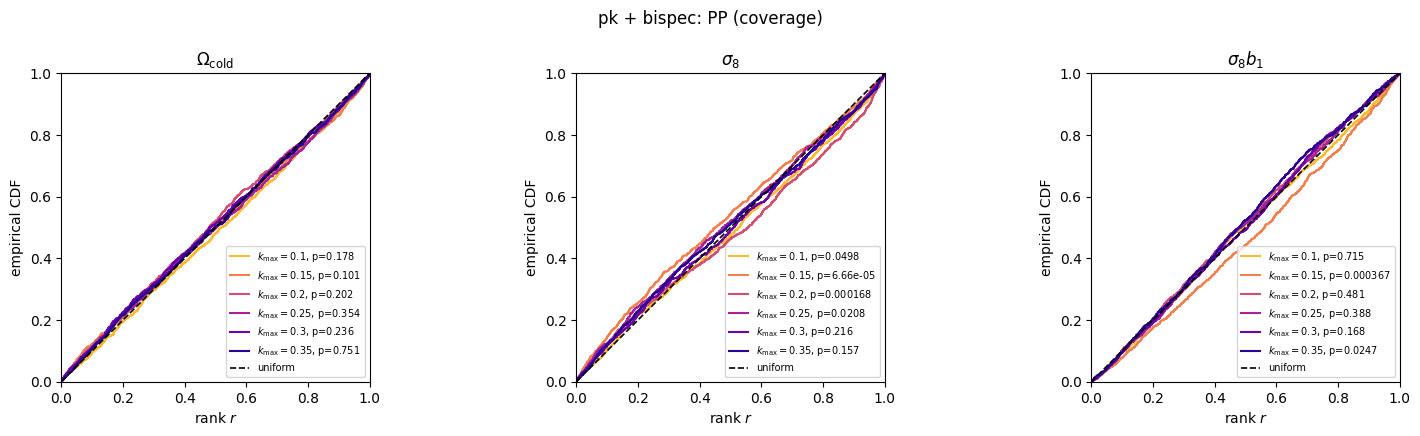

In [5]:
fig_pp_kb = plot_pp_coverage(chains_kb, title=r"pk + bispec: PP (coverage)")
plt.show()


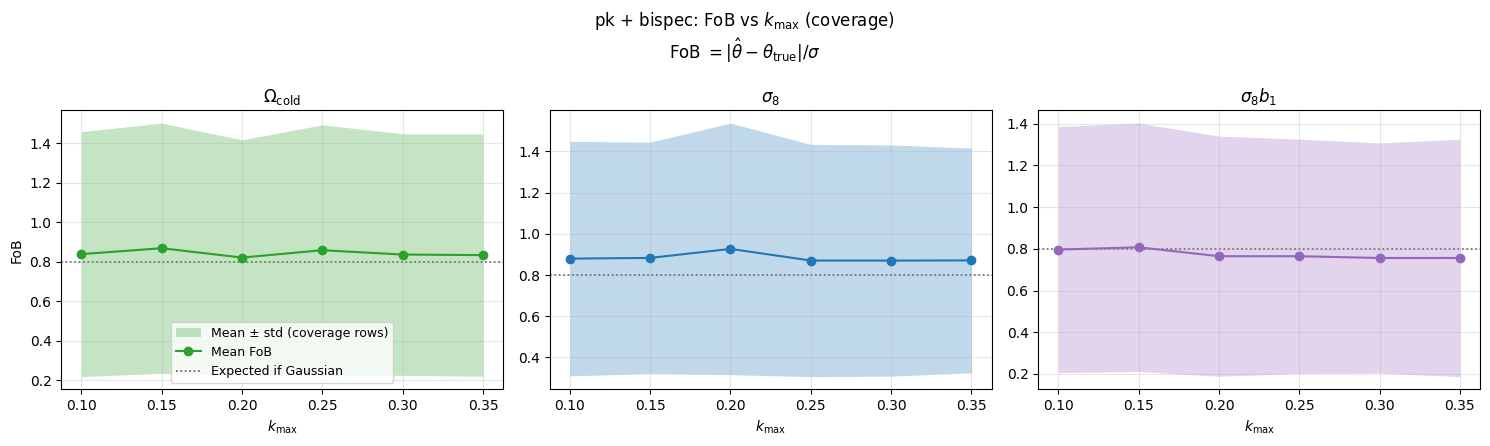

In [6]:
fig_fob_kb = plot_fob_coverage(
    chains_kb,
    title=r"pk + bispec: FoB vs $k_{\mathrm{max}}$ (coverage)",
)
plt.show()


## PGM (`pk` + `pgm`)

In [7]:
chains_kpgm = collect_chains(STAT_ROW_KPGM, TAGS_KMAX_KPGM, family="kpgm")
print(f"loaded {len(chains_kpgm)} pgm chains")


loaded 7 pgm chains


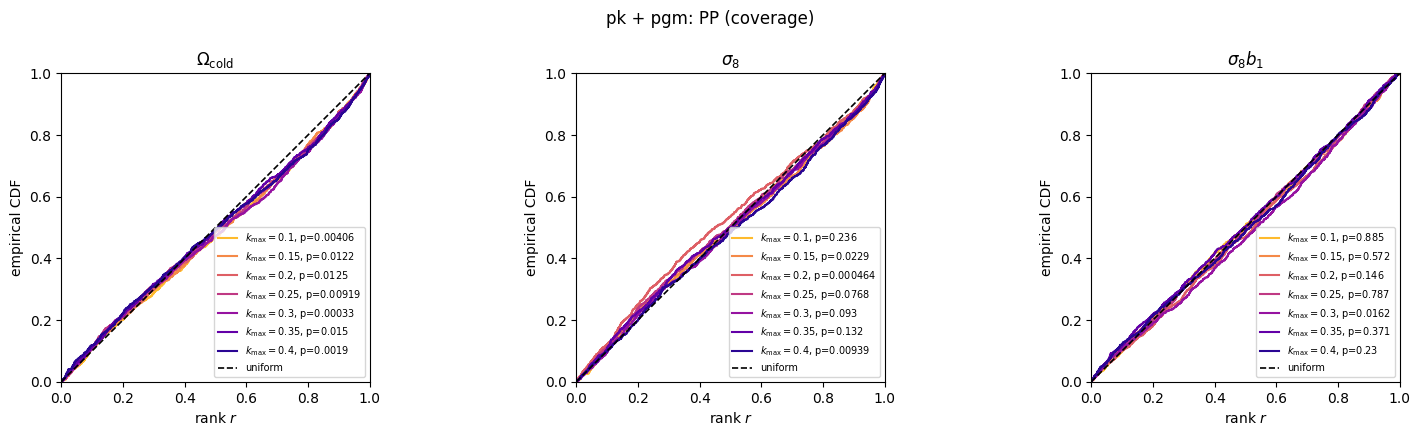

In [8]:
fig_pp_kpgm = plot_pp_coverage(chains_kpgm, title=r"pk + pgm: PP (coverage)")
plt.show()


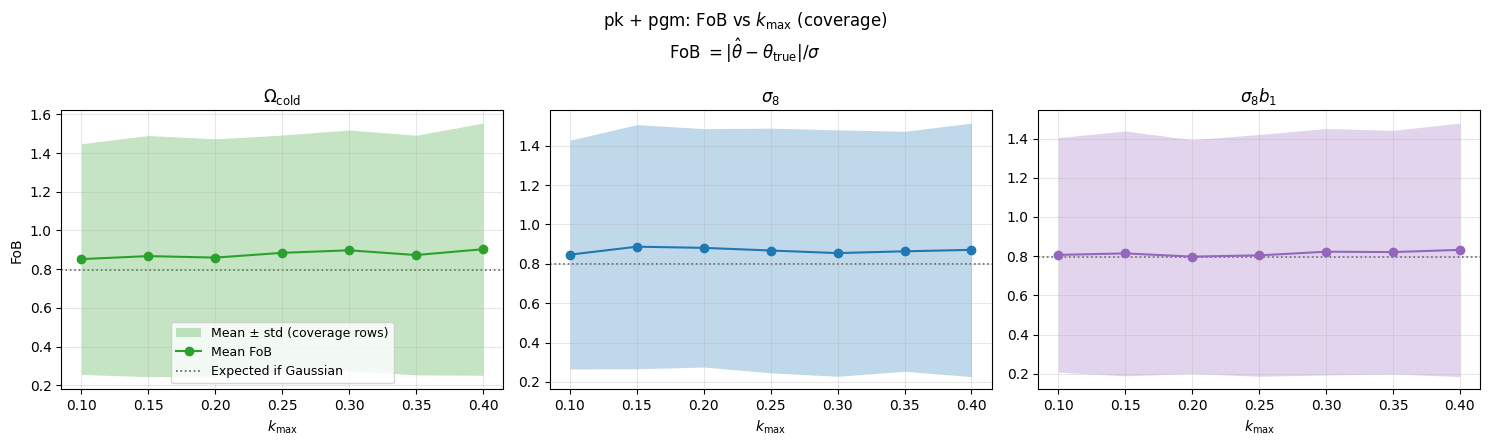

In [9]:
fig_fob_kpgm = plot_fob_coverage(
    chains_kpgm,
    title=r"pk + pgm: FoB vs $k_{\mathrm{max}}$ (coverage)",
)
plt.show()


## SHAMe OOD mock: FoB by scale cut

Loop **`TAG_MOCKS_SHAME`** (three number densities). For **`TAG_MOCK_SHAME`** (default `_nbar0.00022`), **corner contours** use **`plotter.plot_contours_inf`** with **`utils_plot.setup_inference_tags`** / **`setup_shame_mock_test_tags`** / **`data_loader.load_theta_ood`** — same pipeline as **`2026-04-22_inference_SHAMe_best-rand30.ipynb`** (`PARAM_NAMES_ZOOM`, `extents_mid`, `unreparameterize=True`). Chain colors follow **`pp_style_colors`** (``plasma_r``, same sampling as the coverage PP curves). **FoB**: **linestyle** = mock (**`LINE_STYLES_SHAME`**), **color** = parameter (**`PARAM_COLORS`**). Truth needs **`bacco`** for OOD params. Mocks: `utils_model.bias_dict_shame`.


In [10]:
chains_shame_kb_by_nbar = {}
for tm in TAG_MOCKS_SHAME:
    chains_shame_kb_by_nbar[tm] = collect_chains_shame(
        STAT_ROW_KB, TAGS_KMAX_KB, family="kb", tag_mock=tm
    )
    print(f"SHAMe bispec {tm}: {len(chains_shame_kb_by_nbar[tm])} scale-cut chains")


SHAMe bispec _nbar0.00011: 7 scale-cut chains
SHAMe bispec _nbar0.00022: 7 scale-cut chains
SHAMe bispec _nbar0.00054: 7 scale-cut chains


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.1_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.15_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.15_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.2_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/m

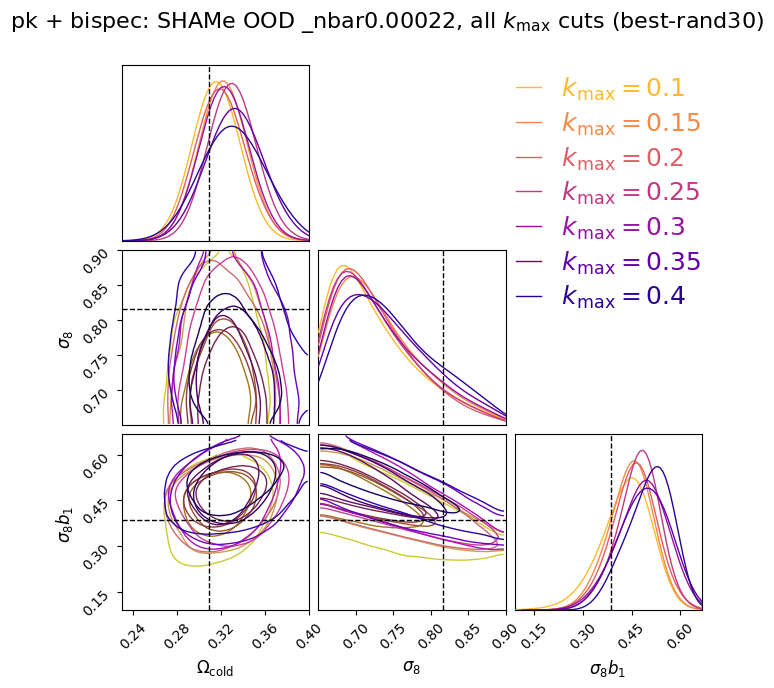

In [11]:
# pk + bispec: corner contours vs k_max (``plotter.plot_contours_inf``, same as 2026-04-22)
statistics_arr_kb = [STAT_ROW_KB] * len(TAGS_KMAX_KB)
tags_inf_kb, _, _, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode,
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN_NOISY,
    statistics_arr=statistics_arr_kb,
    bx=bx,
    tag_noise=TAG_NOISE_TRAIN,
    tag_reparam=tag_reparam,
    n_train=n_train,
    tags_mask=TAGS_KMAX_KB,
)
tags_inf_kb = [t + TAG_INF_BEST_SUFFIX for t in tags_inf_kb]

tag_stats_shame_kb = [
    f"_{'_'.join(s)}{m}" for s, m in zip(statistics_arr_kb, TAGS_KMAX_KB)
]
tags_test_shame_kb = utils_plot.setup_shame_mock_test_tags(
    tag_stats_arr=tag_stats_shame_kb,
    data_mode_test=DATA_MODE_TEST_SHAME,
    tag_mock=TAG_MOCK_SHAME,
)

theta_ood = data_loader.load_theta_ood(
    DATA_MODE_TEST_SHAME,
    TAG_MOCK_SHAME,
    cosmo_param_names_vary=cosmo_param_names_vary_n,
    bias_param_names_vary=bias_param_names_vary_n,
)
theta_obs_true = theta_ood[idx_obs] if theta_ood.ndim == 2 else theta_ood
idxs_zoom = [param_names_vary_n.index(pn) for pn in PARAM_NAMES_ZOOM]
theta_obs_true_show = theta_obs_true[idxs_zoom]

labels_contour_kb = [contour_label_kmax(tm, "kb") for tm in TAGS_KMAX_KB]

plotter.plot_contours_inf(
    param_names=PARAM_NAMES_ZOOM,
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=["sbi"] * len(tags_inf_kb),
    tags_inf=tags_inf_kb,
    tags_test=tags_test_shame_kb,
    colors=pp_style_colors(len(tags_inf_kb)),
    labels=labels_contour_kb,
    title=(
        f"pk + bispec: SHAMe OOD {TAG_MOCK_SHAME}, all "
        + r"$k_{\mathrm{max}}$"
        + " cuts (best-rand30)"
    ),
    extents=extents_mid,
    unreparameterize=False,
)


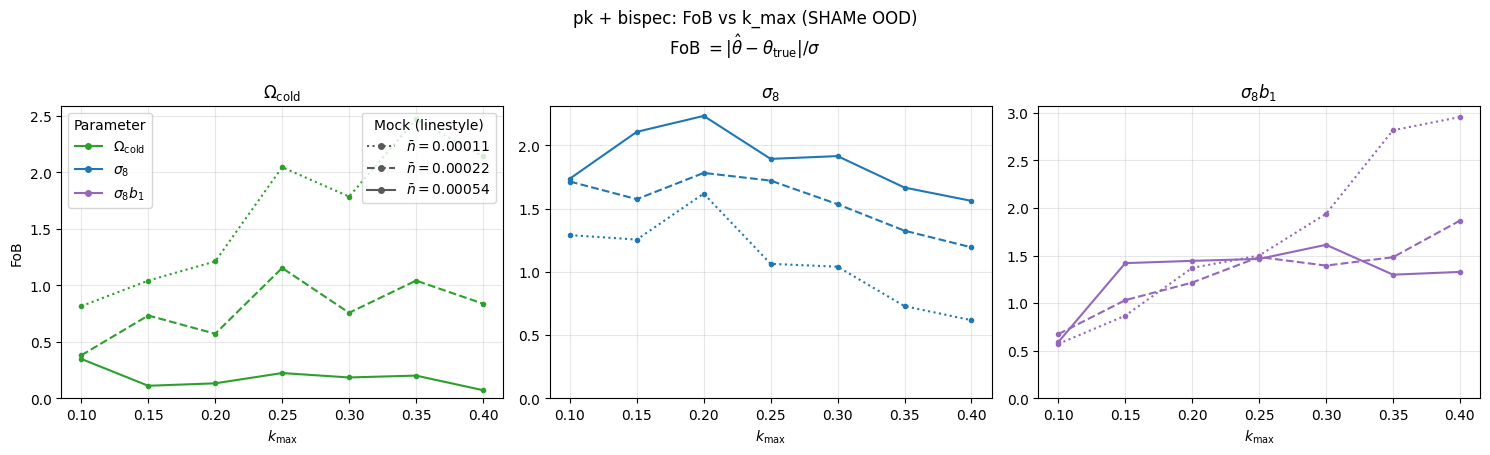

In [12]:
fig_fob_shame_kb = plot_fob_shame_multidensity(
    chains_shame_kb_by_nbar,
    title="pk + bispec: FoB vs k_max (SHAMe OOD)",
    linestyles=LINE_STYLES_SHAME,
)
if fig_fob_shame_kb is not None:
    plt.show()


In [13]:
chains_shame_kpgm_by_nbar = {}
for tm in TAG_MOCKS_SHAME:
    chains_shame_kpgm_by_nbar[tm] = collect_chains_shame(
        STAT_ROW_KPGM, TAGS_KMAX_KPGM, family="kpgm", tag_mock=tm
    )
    print(f"SHAMe pgm {tm}: {len(chains_shame_kpgm_by_nbar[tm])} scale-cut chains")


SHAMe pgm _nbar0.00011: 7 scale-cut chains
SHAMe pgm _nbar0.00022: 7 scale-cut chains
SHAMe pgm _nbar0.00054: 7 scale-cut chains


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.1_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.15_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.15_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.2_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimo

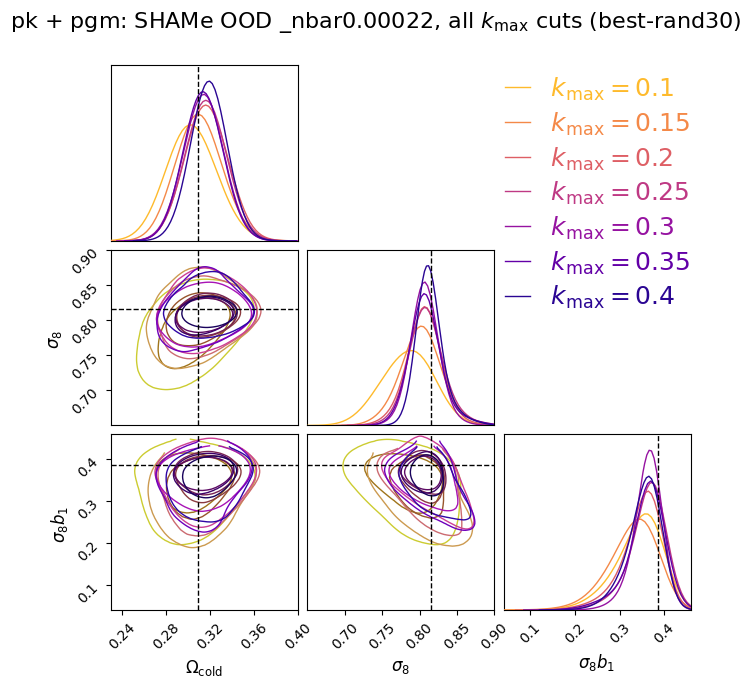

In [14]:
# pk + pgm: corner contours vs k_max (``plotter.plot_contours_inf``, same as 2026-04-22)
statistics_arr_kpgm = [STAT_ROW_KPGM] * len(TAGS_KMAX_KPGM)
tags_inf_kpgm, _, _, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode,
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN_NOISY,
    statistics_arr=statistics_arr_kpgm,
    bx=bx,
    tag_noise=TAG_NOISE_TRAIN,
    tag_reparam=tag_reparam,
    n_train=n_train,
    tags_mask=TAGS_KMAX_KPGM,
)
tags_inf_kpgm = [t + TAG_INF_BEST_SUFFIX for t in tags_inf_kpgm]

tag_stats_shame_kpgm = [
    f"_{'_'.join(s)}{m}" for s, m in zip(statistics_arr_kpgm, TAGS_KMAX_KPGM)
]
tags_test_shame_kpgm = utils_plot.setup_shame_mock_test_tags(
    tag_stats_arr=tag_stats_shame_kpgm,
    data_mode_test=DATA_MODE_TEST_SHAME,
    tag_mock=TAG_MOCK_SHAME,
)

theta_ood = data_loader.load_theta_ood(
    DATA_MODE_TEST_SHAME,
    TAG_MOCK_SHAME,
    cosmo_param_names_vary=cosmo_param_names_vary_n,
    bias_param_names_vary=bias_param_names_vary_n,
)
theta_obs_true = theta_ood[idx_obs] if theta_ood.ndim == 2 else theta_ood
idxs_zoom = [param_names_vary_n.index(pn) for pn in PARAM_NAMES_ZOOM]
theta_obs_true_show = theta_obs_true[idxs_zoom]

labels_contour_kpgm = [contour_label_kmax(tm, "kpgm") for tm in TAGS_KMAX_KPGM]

plotter.plot_contours_inf(
    param_names=PARAM_NAMES_ZOOM,
    idx_obs=idx_obs,
    theta_obs_true=theta_obs_true_show,
    inf_methods=["sbi"] * len(tags_inf_kpgm),
    tags_inf=tags_inf_kpgm,
    tags_test=tags_test_shame_kpgm,
    colors=pp_style_colors(len(tags_inf_kpgm)),
    labels=labels_contour_kpgm,
    title=(
        f"pk + pgm: SHAMe OOD {TAG_MOCK_SHAME}, all "
        + r"$k_{\mathrm{max}}$"
        + " cuts (best-rand30)"
    ),
    extents=extents_mid,
    unreparameterize=False,
)


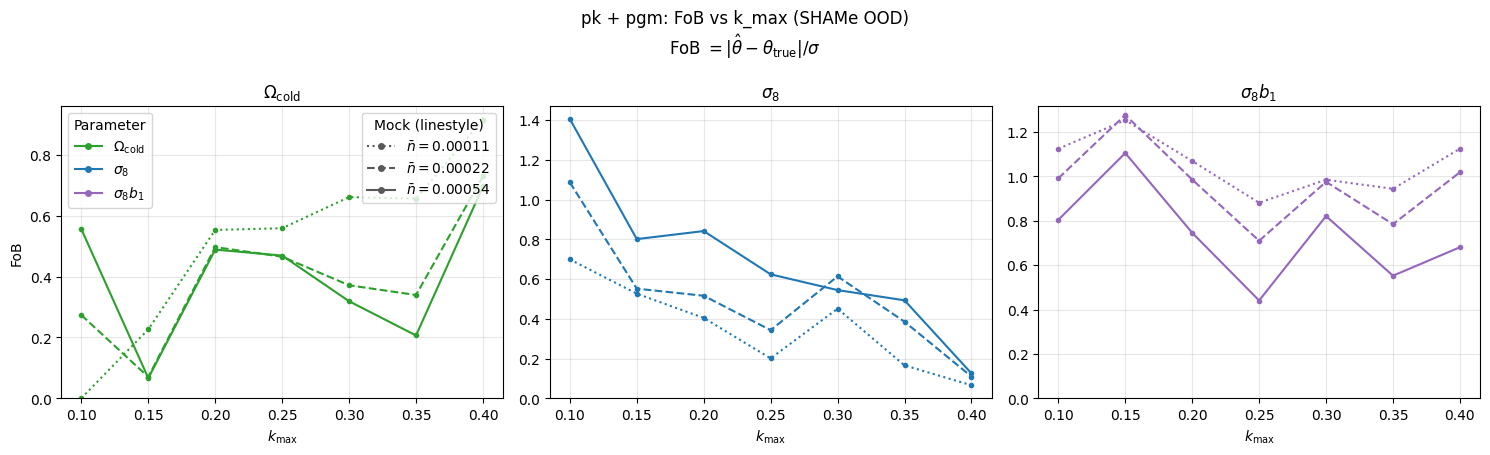

In [15]:
fig_fob_shame_kpgm = plot_fob_shame_multidensity(
    chains_shame_kpgm_by_nbar,
    title="pk + pgm: FoB vs k_max (SHAMe OOD)",
    linestyles=LINE_STYLES_SHAME,
)
if fig_fob_shame_kpgm is not None:
    plt.show()
